# **Evaluating the Responsiveness and Shortcomings of City Services in Washington, DC**

---

#### **Raquel Tartt** (004002111)
#### MATH 014- Data Science
#### Final Data Science Project
#### 04/27/2026

---

## **Table of Contents**
#### Task 01: Introduction
#### Task 02: Objectives & Research Question
#### Task 03: Data Understanding & Cleaning
#### Task 04: Exploratory Data Analysis
#### Task 05: Data Visualization & Interpretation
#### Task 06: Additional Analysis
#### Task 07: Insights and Conclusion 

## **01) Introduction**

#### Washington, D.C relies on a wide network of city service agencies to address everyday safety, health, environmental, construction, and administrative concerns, from sanitation enforcement to tree inspection and planting. The effectiveness of these city service agencies depends not only on the resolution of resident concerns but also on how quickly and consistently these concerns are addressed. 

#### This project examines the responsiveness of city services using the "311 City Service Request in 2025" dataset published by DC Open Data. By analyzing request data, I will examine response times, completion rates, and potential disparities across different types of city services. The dataset includes variables such as service description, city service organization, service order date, and resolution data, which offer insight into resolution disparities and the efficiency of various agencies.

#### Through the identification of patterns and frequent shortcomings, this project aims to highlight areas for improvement in efficiency in D.C city services.

#### **Dataset**: https://opendata.dc.gov/datasets/DCGIS::311-city-service-requests-in-2025/explore

## **02) Research Questions**

#### *1) To what extent are city service agencies in Washington, DC, efficient, as measured by resolution times across various types of service requests?*

#### *2) Do significant differences in resolution times exist between different city service agencies in Washington, DC?*

#### *3) Do significant differences in resolution times exist between different DC Wards?*

## **03) Data Understanding and Cleaning**

In [428]:
import pandas as pd 

In [429]:
df = pd.read_csv("311_City_Service_Requests_in_2025.csv")

/var/folders/0j/cnv3f5cx1k57q75tsyfmmfqw0000gn/T/ipykernel_38743/504332971.py:1: DtypeWarning:

Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.



#### *Displaying Data*

In [430]:
df.head(7)

,X,Y,SERVICEREQUESTID,STREETADDRESS,CITY,STATE,ZIPCODE,SERVICECODE,SERVICECODEDESCRIPTION,SERVICETYPECODEDESCRIPTION,...,WARD,XCOORD,YCOORD,LATITUDE,LONGITUDE,MARADDRESSREPOSITORYID,GLOBALID,CREATED,EDITED,OBJECTID
0,401366.06,134524.87,25-00000002,1438 K STREET SE,WASHINGTON,DC,20003.0,S0031,Bulk Collection,SWMA- Solid Waste Management Admistration,...,Ward 6,401366.06,134524.87,38.878555,-76.984257,63442,{2AA431E0-F9C7-766F-E063-792F520A1480},NaN,NaN,11865239
1,396942.87,140394.80,25-00000003,1511 PARK ROAD NW,WASHINGTON,DC,20010.0,S0261,Parking Enforcement,PEMA- Parking Enforcement Management Administr...,...,Ward 1,396942.87,140394.80,38.931430,-77.035259,234437,{2AA431E0-F9C8-766F-E063-792F520A1480},NaN,NaN,11865240
2,393757.08,140604.28,25-00000004,3614 MACOMB STREET NW,WASHINGTON,DC,20016.0,S0031,Bulk Collection,SWMA- Solid Waste Management Admistration,...,Ward 3,393757.08,140604.28,38.933299,-77.072003,328204,{2AA431E0-F9C9-766F-E063-792F520A1480},NaN,NaN,11865241
3,401561.80,133400.44,25-00000005,1728 16TH STREET SE,WASHINGTON,DC,20020.0,S0031,Bulk Collection,SWMA- Solid Waste Management Admistration,...,Ward 8,401561.80,133400.44,38.868426,-76.982003,56949,{2AA431E0-F9CA-766F-E063-792F520A1480},NaN,NaN,11865242
4,399909.21,137153.67,25-00000007,327 K STREET NE,WASHINGTON,DC,20002.0,S0031,Bulk Collection,SWMA- Solid Waste Management Admistration,...,Ward 6,399909.21,137153.67,38.902238,-77.001047,37329,{2AA431E0-F9CB-766F-E063-792F520A1480},NaN,NaN,11865243
5,399801.36,135958.64,25-00000008,116 3RD STREET NE,WASHINGTON,DC,20002.0,S0031,Bulk Collection,SWMA- Solid Waste Management Admistration,...,Ward 6,399801.36,135958.64,38.891472,-77.002290,277613,{2AA431E0-F9CC-766F-E063-792F520A1480},NaN,NaN,11865244
6,404091.48,136164.64,25-00000010,238 35TH STREET NE,WASHINGTON,DC,20019.0,S0457,Tree Inspection,Urban Forrestry,...,Ward 7,404091.48,136164.64,38.893319,-76.952837,47928,{2AA431E0-F9CD-766F-E063-792F520A1480},NaN,NaN,11865245


#### *Examine Shape of Data*

In [431]:
dimensions = df.shape

In [432]:
dimensions 

(440600, 33)

#### *Examine Columns*

In [433]:
df.columns

Index(['X', 'Y', 'SERVICEREQUESTID', 'STREETADDRESS', 'CITY', 'STATE',
       'ZIPCODE', 'SERVICECODE', 'SERVICECODEDESCRIPTION',
       'SERVICETYPECODEDESCRIPTION', 'ORGANIZATIONACRONYM', 'SERVICECALLCOUNT',
       'ADDDATE', 'RESOLUTIONDATE', 'SERVICEDUEDATE', 'SERVICEORDERDATE',
       'INSPECTIONFLAG', 'INSPECTIONDATE', 'INSPECTORNAME',
       'SERVICEORDERSTATUS', 'STATUS_CODE', 'PRIORITY', 'DETAILS', 'WARD',
       'XCOORD', 'YCOORD', 'LATITUDE', 'LONGITUDE', 'MARADDRESSREPOSITORYID',
       'GLOBALID', 'CREATED', 'EDITED', 'OBJECTID'],
      dtype='object')

In [434]:
df.columns =['X', 'Y', 'Service_Request_ID', 'Street_Address', 'City', 'State',
       'Zip_Code', 'Service_Code', 'Service_Code_Description',
       'Service_Type_Code_Description', 'Organization_Acronym', 'Service_Call_Count',
       'Request_Add_Date', 'Resolution_Date', 'Service_Due_Date', 'Service_Order_Date',
       'Inspection_Flag', 'Inspection_Date', 'Inspector_Name',
       'Service_Order_Status', 'Status_Code', 'Priority', 'Details', 'Ward',
       'X_Coord', 'Y_Coord', 'Latitude', 'Longitude', 'March_Address_Repository_ID',
       'Global_ID', 'Created', 'Edited', 'Object_ID']

In [435]:
df.columns

Index(['X', 'Y', 'Service_Request_ID', 'Street_Address', 'City', 'State',
       'Zip_Code', 'Service_Code', 'Service_Code_Description',
       'Service_Type_Code_Description', 'Organization_Acronym',
       'Service_Call_Count', 'Request_Add_Date', 'Resolution_Date',
       'Service_Due_Date', 'Service_Order_Date', 'Inspection_Flag',
       'Inspection_Date', 'Inspector_Name', 'Service_Order_Status',
       'Status_Code', 'Priority', 'Details', 'Ward', 'X_Coord', 'Y_Coord',
       'Latitude', 'Longitude', 'March_Address_Repository_ID', 'Global_ID',
       'Created', 'Edited', 'Object_ID'],
      dtype='object')

#### *Examine Data Types*

In [436]:
df.dtypes

X                                float64
Y                                float64
Service_Request_ID                object
Street_Address                    object
City                              object
State                             object
Zip_Code                         float64
Service_Code                      object
Service_Code_Description          object
Service_Type_Code_Description     object
Organization_Acronym              object
Service_Call_Count                 int64
Request_Add_Date                  object
Resolution_Date                   object
Service_Due_Date                  object
Service_Order_Date                object
Inspection_Flag                  float64
Inspection_Date                  float64
Inspector_Name                   float64
Service_Order_Status              object
Status_Code                      float64
Priority                          object
Details                           object
Ward                              object
X_Coord         

#### *Compute Summary Statistics*

In [437]:
df.describe(include='all')

,X,Y,Service_Request_ID,Street_Address,City,State,Zip_Code,Service_Code,Service_Code_Description,Service_Type_Code_Description,...,Ward,X_Coord,Y_Coord,Latitude,Longitude,March_Address_Repository_ID,Global_ID,Created,Edited,Object_ID
count,440600.000000,440600.000000,440600,437937,440600,440600,440501.000000,440600,440600,417735,...,440590,440600.000000,440600.000000,440600.000000,440600.000000,440600.000000,440600,0.0,0.0,4.406000e+05
unique,NaN,NaN,440600,106817,1,1,NaN,120,124,23,...,8,NaN,NaN,NaN,NaN,NaN,440600,NaN,NaN,NaN
top,NaN,NaN,25-00000002,2720 MARTIN LUTHER KING JR AVENUE SE,WASHINGTON,DC,NaN,S0031,Bulk Collection,SWMA- Solid Waste Management Admistration,...,Ward 5,NaN,NaN,NaN,NaN,NaN,{2AA431E0-F9C7-766F-E063-792F520A1480},NaN,NaN,NaN
freq,NaN,NaN,1,9700,440600,440600,NaN,67414,67414,174696,...,66950,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN
mean,399006.699792,138281.291472,NaN,NaN,NaN,NaN,20012.973408,NaN,NaN,NaN,...,NaN,399006.699791,138281.291473,38.912517,-77.010991,237681.688207,NaN,NaN,NaN,1.211663e+07
std,5182.320397,3876.424690,NaN,NaN,NaN,NaN,26.110017,NaN,NaN,NaN,...,NaN,5182.320397,3876.424690,0.032573,0.037523,215671.385619,NaN,NaN,NaN,1.438879e+05
min,-77.107000,38.831000,NaN,NaN,NaN,NaN,20001.000000,NaN,NaN,NaN,...,NaN,-77.107110,38.830959,38.808947,-77.118281,1.000000,NaN,NaN,NaN,1.186524e+07
25%,397131.787500,136038.760000,NaN,NaN,NaN,NaN,20003.000000,NaN,NaN,NaN,...,NaN,397131.787500,136038.760000,38.892193,-77.033080,66463.000000,NaN,NaN,NaN,1.199717e+07
50%,399028.385000,138284.760000,NaN,NaN,NaN,NaN,20011.000000,NaN,NaN,NaN,...,NaN,399028.385000,138284.760000,38.912422,-77.011189,236071.000000,NaN,NaN,NaN,1.211235e+07
75%,401036.730000,140778.680000,NaN,NaN,NaN,NaN,20018.000000,NaN,NaN,NaN,...,NaN,401036.730000,140778.680000,38.934889,-76.988048,278064.000000,NaN,NaN,NaN,1.223416e+07


#### The most common requests made in Washington, D.C are "Bulk Collection" requests, which are handled by the Solid Waste Management Administration (SWMA). Additonally, most requests are being made from residents who reside in Ward 5. The unique variable descriptive statistic shows that there are 124 types of services requested and 23 city services agencies listed in this data set. Information examining response times cannot be drawn at this time, due to the format of the date-related columns. 

#### **<u>Data Cleaning</u>**

#### *Formating Data*

In [438]:
df["response_time"] = pd.to_datetime(df["Resolution_Date"]) - pd.to_datetime(df["Request_Add_Date"])
#Convert numerical/time/date data 

##### Converting from the MONTH/DAY/YEAR HOUR/MINUTE format to days, so that data is easier to compare and analyze  

In [439]:
df["response_time"]

0        24 days 11:28:36
1         0 days 00:18:52
2        13 days 12:22:07
3        22 days 12:28:20
4        24 days 07:45:50
               ...       
440595   12 days 10:29:49
440596    0 days 00:51:12
440597    7 days 03:34:06
440598    3 days 22:18:54
440599   30 days 20:57:40
Name: response_time, Length: 440600, dtype: timedelta64[ns]

#### *Dropping Columns*

In [440]:
df = df[df["Resolution_Date"].notna()]

##### If there is not a resolution date, there is no way to examine responsiveness  

In [441]:
df = df.dropna(subset=["Request_Add_Date", "Resolution_Date", "Organization_Acronym"])

##### Dropping missing data points that are in the columns that I plan to examine.

In [442]:
df = df.drop_duplicates()

##### Dropping unnecessary data points. Duplicates are unnecessary and can mistakenly impact final conclusions

In [443]:
df['Priority'].value_counts()

Priority
Standard     433512
Urgent          281
High            280
Emergency       104
Medium           21
Name: count, dtype: int64

##### Because there is variation between the responses in "Priority," I will keep the column, as it might provide insight into who is served, and how quickly. 

In [444]:
df = df.drop('X' , axis=1)

In [445]:
df = df.drop('Y', axis=1)

In [446]:
df = df.drop('Service_Request_ID', axis=1)

In [447]:
df = df.drop('Status_Code', axis=1) 

In [448]:
df = df.drop('Details', axis=1)

In [449]:
df = df.drop('X_Coord', axis=1)

In [450]:
df = df.drop('Y_Coord', axis=1)

In [451]:
df = df.drop (['Latitude', 'Longitude', 'March_Address_Repository_ID', 'Global_ID',
       'Created', 'Edited', 'Object_ID', 'Service_Order_Date','Service_Code'] , axis=1)

In [452]:
df = df.drop(['Street_Address', 'Service_Due_Date'], axis=1)

In [453]:
df = df.drop(['Inspection_Flag', 'Inspection_Date', 'Inspector_Name'], axis=1)

In [454]:
df.head()

,City,State,Zip_Code,Service_Code_Description,Service_Type_Code_Description,Organization_Acronym,Service_Call_Count,Request_Add_Date,Resolution_Date,Service_Order_Status,Priority,Ward,response_time
0,WASHINGTON,DC,20003.0,Bulk Collection,SWMA- Solid Waste Management Admistration,DPW,1,2025/01/01 05:22:23+00,2025/01/25 16:50:59+00,Closed,Standard,Ward 6,24 days 11:28:36
1,WASHINGTON,DC,20010.0,Parking Enforcement,PEMA- Parking Enforcement Management Administr...,DPW,1,2025/01/01 05:23:49+00,2025/01/01 05:42:41+00,Closed,Standard,Ward 1,0 days 00:18:52
2,WASHINGTON,DC,20016.0,Bulk Collection,SWMA- Solid Waste Management Admistration,DPW,1,2025/01/01 05:24:13+00,2025/01/14 17:46:20+00,Closed,Standard,Ward 3,13 days 12:22:07
3,WASHINGTON,DC,20020.0,Bulk Collection,SWMA- Solid Waste Management Admistration,DPW,1,2025/01/01 05:28:59+00,2025/01/23 17:57:19+00,Closed,Standard,Ward 8,22 days 12:28:20
4,WASHINGTON,DC,20002.0,Bulk Collection,SWMA- Solid Waste Management Admistration,DPW,1,2025/01/01 05:29:54+00,2025/01/25 13:15:44+00,Closed,Standard,Ward 6,24 days 07:45:50


##### Personally identifiable information, such as Street Address, March Address Repository ID, and Inspector Name were removed for privacy purposes. 

##### X, Y, X coordinate, Y coordinate, Latitude, and Longitude columns were removed, as they were redundant and unnecessary.

##### Service Order Date and Status Due Date were removed because the time/date data was redundant 

##### Other columns, such as Details, Status Code, Inspection Flag, and Inspection Date, were removed as such information is unneccessary to this projects analysis 

In [455]:
df.isna().sum()

City                                 0
State                                0
Zip_Code                            97
Service_Code_Description             0
Service_Type_Code_Description    21101
Organization_Acronym                 0
Service_Call_Count                   0
Request_Add_Date                     0
Resolution_Date                      0
Service_Order_Status                 0
Priority                             0
Ward                                10
response_time                        0
dtype: int64

In [456]:
df = df.drop ('Zip_Code', axis=1)

##### Zip Code were dropped due to their missing variables. Their omission has no effect on the analysis, as Organization Acronym and Ward will allow me to explore disparities between agencies and geographic locations.

In [457]:
df["Service_Order_Status"].value_counts()

Service_Order_Status
Closed                  422131
Closed (Duplicate)        8762
Canceled                  2541
Closed (Transferred)       764
Name: count, dtype: int64

In [458]:
df = df[df["Service_Order_Status"] != "Closed (Duplicate)"]

##### I removed duplicate entries from the data to better understand the percentage of requests that are resolved, transferred, or canceled. Even if the same issue was reported multiple times, it would only be counted as resolved for one request in the dataset. This could give the impression that fewer resolutions are made than actually occur.

## **04) Exploratory Data Analysis**

#### *Summary Statistics*

In [459]:
df["response_time"].describe()

count                        425436
mean      9 days 07:37:59.428515687
std      26 days 19:16:15.438376576
min                 0 days 00:00:00
25%          0 days 03:52:04.750000
50%                 2 days 21:55:14
75%          8 days 01:40:09.250000
max               452 days 21:53:56
Name: response_time, dtype: object

##### Before removing outliers, this summary shows that the average/mean reponse time is 9 days, with 75% of requests being resolved within 8 days.

In [460]:
df["Service_Code_Description"].describe()

count              425436
unique                115
top       Bulk Collection
freq                67009
Name: Service_Code_Description, dtype: object

In [461]:
df["Ward"].describe()

count     425426
unique         8
top       Ward 5
freq       64742
Name: Ward, dtype: object

#### *Frequency & Value Counts* 

In [462]:
df["Organization_Acronym"].value_counts()

Organization_Acronym
DPW         316907
DDOT         57564
OUC          19647
DOH          16683
DMV           6197
DOB           3639
DGS           1745
Serve DC      1529
DOEE           688
ORM            462
DC Water       330
FEMS            28
DFHV            17
Name: count, dtype: int64

#### *Group Level Comparisons*

In [463]:
df.groupby("Organization_Acronym")["response_time"].mean().sort_values()

Organization_Acronym
DC Water               0 days 00:00:00
Serve DC               0 days 00:00:00
OUC          0 days 00:00:02.145213009
DOH          2 days 15:30:43.642989869
DOEE         5 days 12:14:05.627906976
DPW          7 days 20:47:00.726777887
DMV          8 days 09:41:56.916895271
DOB         10 days 17:48:41.133827974
DDOT        20 days 09:30:05.963119310
DFHV        22 days 04:23:48.411764706
ORM         39 days 05:58:24.917748917
DGS         78 days 09:06:51.488252149
FEMS       106 days 14:59:18.964285714
Name: response_time, dtype: timedelta64[ns]

##### This shows that D.C Fire and Emergency Medical Services Department (FEMS) has the worst response time, as shown by an average period of 21 days between request filling and resolution. 

In [464]:
df.groupby("Ward")["response_time"].mean().sort_values()

Ward
Ward 8    5 days 16:35:45.402635775
Ward 7    8 days 04:35:36.406359151
Ward 6    9 days 02:55:01.495987028
Ward 5    9 days 10:14:55.475997034
Ward 1    9 days 11:18:41.934900975
Ward 2   10 days 00:35:09.311999830
Ward 4   10 days 12:00:44.167726625
Ward 3   11 days 23:12:14.137276341
Name: response_time, dtype: timedelta64[ns]

In [465]:
df.groupby("Service_Code_Description")["response_time"].mean().sort_values()

Service_Code_Description
Signed Street Sweeping Missed                                                                             0 days 00:00:00
Residential Snow Removal (ServeDC)                                                                        0 days 00:00:00
Hypothermia Shelter Information                                                                           0 days 00:00:00
Green Infrastructure Maintenance                                                                          0 days 00:00:00
Emergency - Power Outage/Wires Down                                                                       0 days 00:00:00
                                                                                                          ...            
FEMS - Fire Safety Education                                                                     154 days 09:48:27.500000
DC Indoor and Outdoor Pool Maintenance  (DGS)                                                 155 days 02:03:30.092592592

In [466]:
df["Service_Order_Status"].value_counts()

Service_Order_Status
Closed                  422131
Canceled                  2541
Closed (Transferred)       764
Name: count, dtype: int64

In [467]:
df["Service_Order_Status"].value_counts(normalize=True) * 100
#Convert into percentage values 

Service_Order_Status
Closed                  99.22315
Canceled                 0.59727
Closed (Transferred)     0.17958
Name: proportion, dtype: float64

##### This shows that 99% of requests are eventually resolved by the angency contacted. 

#### *Outlier Detection*

##### The majority of requests are resolved within 9 days. Therefore, the max value of 452 days exists as an extreme outlier, which should be removed.¶

In [468]:
df = df[df["response_time"] <= pd.Timedelta(days=30)]
#Remove entries above 30 days 

##### Removed entries with response times greater than 30 days.

In [469]:
df.sort_values(by="response_time", ascending=False).head()

,City,State,Service_Code_Description,Service_Type_Code_Description,Organization_Acronym,Service_Call_Count,Request_Add_Date,Resolution_Date,Service_Order_Status,Priority,Ward,response_time
409446,WASHINGTON,DC,Scheduled Yard Waste,SWMA- Solid Waste Management Administration,DPW,1,2025/11/23 18:33:38+00,2025/12/23 18:33:07+00,Closed,Standard,Ward 3,29 days 23:59:29
408978,WASHINGTON,DC,Scheduled Yard Waste,SWMA- Solid Waste Management Administration,DPW,1,2025/11/22 17:54:20+00,2025/12/22 17:53:11+00,Closed,Standard,Ward 5,29 days 23:58:51
358799,WASHINGTON,DC,Scheduled Yard Waste,SWMA- Solid Waste Management Administration,DPW,1,2025/10/08 18:14:07+00,2025/11/07 18:11:39+00,Closed,Standard,Ward 5,29 days 23:57:32
409256,WASHINGTON,DC,Scheduled Yard Waste,SWMA- Solid Waste Management Administration,DPW,1,2025/11/23 17:56:06+00,2025/12/23 17:52:45+00,Closed,Standard,Ward 3,29 days 23:56:39
148298,WASHINGTON,DC,Container Removal,SWMA- Solid Waste Management Admistration,DPW,1,2025/05/06 14:51:59+00,2025/06/05 14:47:22+00,Closed,Standard,Ward 2,29 days 23:55:23


In [470]:
df["response_time"].describe()

count                       403732
mean     4 days 17:52:23.220586923
std      5 days 20:49:54.532391624
min                0 days 00:00:00
25%                0 days 03:10:33
50%         2 days 14:56:00.500000
75%         7 days 04:10:26.750000
max               29 days 23:59:29
Name: response_time, dtype: object

##### After removing the outliers by removing response times greater than 30 days, the mean response time has decreased to 4 days, with 75% of requests being resolved in 7 days. 

#### *Top & Bottom Performers* 

In [471]:
df.groupby("Organization_Acronym")["response_time"].mean().nsmallest(10)

Organization_Acronym
DC Water             0 days 00:00:00
Serve DC             0 days 00:00:00
OUC        0 days 00:00:02.145213009
DOH        2 days 06:51:43.930712737
DDOT       2 days 20:13:34.520766512
DGS        3 days 00:23:24.152749490
DOEE       4 days 05:27:56.408284023
DPW        5 days 09:19:23.403349472
DMV        8 days 09:41:56.916895271
DOB        9 days 12:03:24.582183908
Name: response_time, dtype: timedelta64[ns]

In [472]:
(df["Organization_Acronym"] == "DC Water").sum()

np.int64(330)

In [473]:
(df["Organization_Acronym"] == "Serve DC").sum()

np.int64(1529)

In [474]:
(df["Organization_Acronym"] == "OUC").sum()

np.int64(19647)

##### This shows that DC Water, Serve DC, and Office of Unified Communications (OUC) have the best response time, as shown by an average response period of 0 days between request filling and resolution.

##### I reviewed the frequency of entries mentioning DC Water, Serve DC, and OUC to confirm that they were consistently included in the data set, ensuring that a response time of zero was not just an isolated incident.

In [475]:
df.groupby("Organization_Acronym")["response_time"].mean().nlargest(10)

Organization_Acronym
FEMS      21 days 10:34:40.500000
ORM    13 days 17:28:18.487903225
DFHV   12 days 12:22:29.333333333
DOB     9 days 12:03:24.582183908
DMV     8 days 09:41:56.916895271
DPW     5 days 09:19:23.403349472
DOEE    4 days 05:27:56.408284023
DGS     3 days 00:23:24.152749490
DDOT    2 days 20:13:34.520766512
DOH     2 days 06:51:43.930712737
Name: response_time, dtype: timedelta64[ns]

In [476]:
(df["Organization_Acronym"] == "FEMS").sum()

np.int64(4)

##### This shows that D.C Fire and Emergency Medical Services Department (FEMS) has the worst response time, as shown by an average period of 21 days between request filling and resolution. However, because the data set has limited frequency, I cannot definitively conclude that FEMS is the lowest performer, as this average may be influenced by isolated incidents.

In [477]:
(df["Organization_Acronym"] == "ORM").sum()

np.int64(248)

In [478]:
(df["Organization_Acronym"] == "DFHV").sum()

np.int64(15)

In [479]:
(df["Organization_Acronym"] == "DOB").sum()

np.int64(3480)

In [480]:
(df["Organization_Acronym"] == "DMV").sum()

np.int64(6197)

##### DC Department of Buildings (DOB) and Department of Motor Vehicles (DMV) are more accurate bottom perfomers because of their frequency in the dataset.  

## **5) Data Visualization**

In [481]:
!pip install cufflinks

# Then import all your libraries
import plotly.express as px
import pandas as pd
from plotly import graph_objects as go
import numpy as np
%matplotlib inline

from plotly import __version__
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot

print(__version__) # requires version >= 6.1.2

import matplotlib.pyplot as plt
import seaborn as sns
import cufflinks as cf

python(46711) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


6.3.0


In [482]:
df["response_time"] = pd.to_datetime(df["Resolution_Date"]) - pd.to_datetime(df["Request_Add_Date"])
df["response_time_days"] = df["response_time"].dt.days

#### <u>Visualization 1: Quantity of Service Requests per Agency<u>

#### Statement of Intent
##### This visualization examines the overall distribution of consumer requests by agency to understand the workload of each agency/organization.

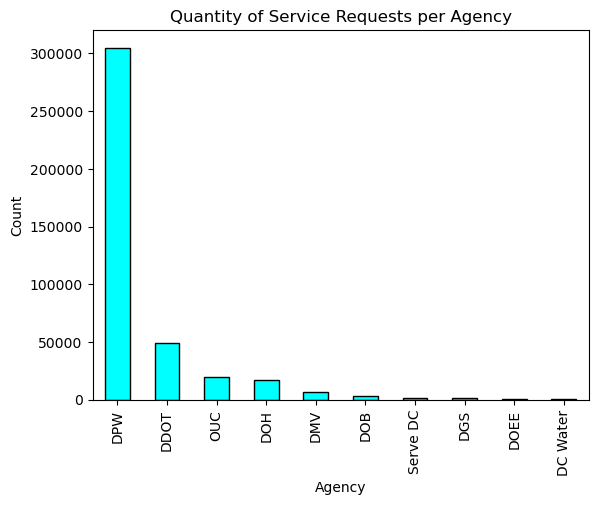

In [483]:
plt.figure()
df['Organization_Acronym'].value_counts().head(10).plot(
    kind='bar',colormap='cool', edgecolor='black')
plt.xlabel("Agency")
plt.ylabel("Count") 
plt.title("Quantity of Service Requests per Agency")
plt.xticks(rotation=90)
plt.show()

#### Interpretation

##### The distribution shows that most of Washington, DC's service requests fall under the jurisdiction of the Department of Public Works (DPW). This suggests that a general analysis of the data set, without intentional filtering and comparison, would produce a biased and ungeneralizable conclusion regarding efficiency, as DPW data is dominant in this dataset.  

#### <u>Visualization 2: Diversity in Services Requested <u>

#### Statement of Intent 
##### This visualization examines the distribution of services requested in Washington, DC to observe trends in customer needs.

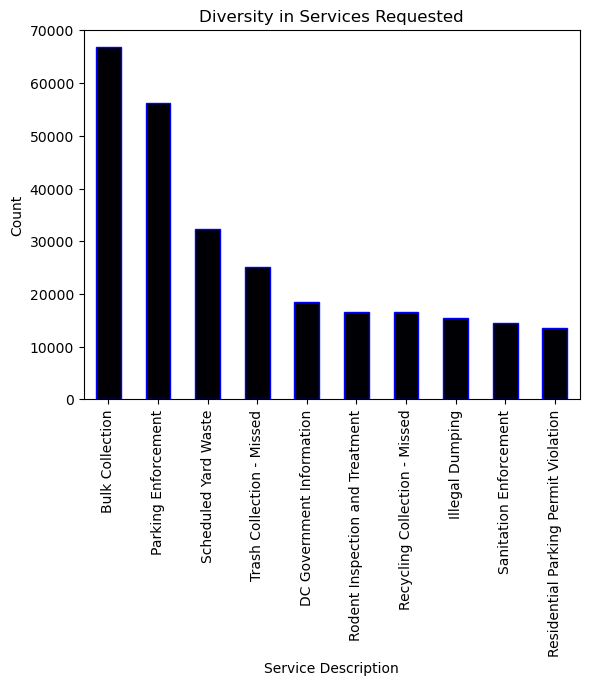

In [484]:
plt.figure()
df['Service_Code_Description'].value_counts().head(10).plot(
    kind='bar',colormap='magma', edgecolor='blue')
plt.xlabel("Service Description")
plt.ylabel("Count") 
plt.title("Diversity in Services Requested")
plt.xticks(rotation=90)
plt.show()

#### Interpretation

##### The data indicates that the majority of service requests in Washington, DC, are related to Bulk Collection, Parking Enforcement, and Scheduled Yard Waste. This visualization highlights recurring issues and requests, suggesting that DC could implement proactive measures to address these concerns without requiring citizens to make requests. For instance, this information could inspire DC to increase surveillance or police presence to manage parking-related issues without relying on citizen involvement. Given that efficiency is the topic of this project, examining the efficiency in a way that could impact policy is in alignment with this project's objectives.

#### <u>Visualization 3: Response Time by Angency <u>

#### Statement of Intent 
##### This interactive visualization shows how response times vary across agencies

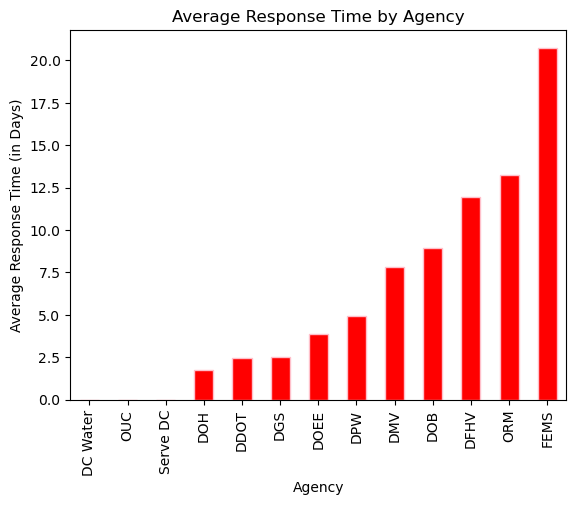

In [485]:
avg_by_agency = df.groupby("Organization_Acronym")["response_time_days"].mean().sort_values()

#Convert to Plotly Express
avg_by_agency_df = avg_by_agency.reset_index()
avg_by_agency_df.columns = ["agency", "avg_time"] 


fig = px.bar(avg_by_agency_df, x="agency", y="avg_time", hover_data=["avg_time"])
fig.show()

plt.figure()
avg_by_agency.plot(kind="bar", colormap="autumn", edgecolor='pink')
plt.xlabel("Agency")
plt.ylabel("Average Response Time (in Days)")
plt.title("Average Response Time by Agency")
plt.xticks(rotation=90)
plt.show()

#### Interpretation

##### The chart reveals clear differences in response times across agencies, with some departments resolving requests more quickly than others. This visualization displays that DC Water, Office of Unified Communications (OUC), and Serve DC have very fast resolution rates (0 days), while  Office of Risk Management (ORM) and Fire and Medical Emergency Services (FEMS), have very slow resolution rates (x>13). 

#### <u>Visualization 4: Average Response Time by Ward <u>

#### Statement of Intent 
##### This bar chart compares average response times across DC wards to identify differences in performance and efficiency in different geographical regions. 

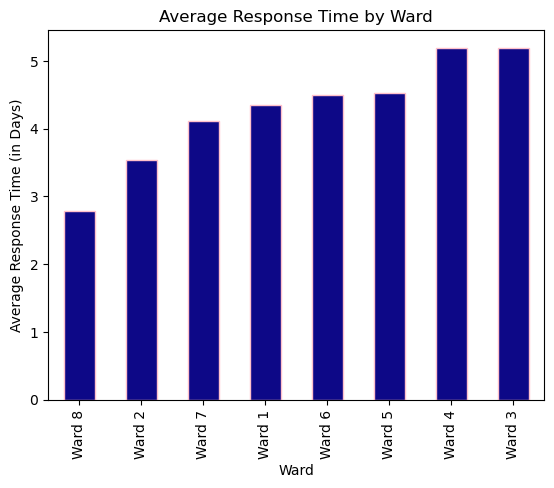

In [486]:
avg_by_agency = df.groupby("Ward")["response_time_days"].mean().sort_values()

plt.figure()
avg_by_agency.plot(kind="bar", colormap="plasma", edgecolor='pink')
plt.xlabel("Ward")
plt.ylabel("Average Response Time (in Days)")
plt.title("Average Response Time by Ward")
plt.xticks(rotation=90)
plt.show()

#### Interpretation

##### The chart reveals some differences in response times across wards, with some wards resolving requests more quickly than others. This visualization shows that Wards 8 and 2 have the fastest resolution times, with most requests being resolved within 4 days. In contrast, Wards 4 and 3 have slower resolution times, with most requests being resolved after more than 5 days.

#### <u>Visualization 5:  Resolution Time Distribution by Agency <u>

#### Statement of Intent 
##### This boxplot examines the spread of response times across each agency, highlighting existing outliers.

<Figure size 640x480 with 0 Axes>

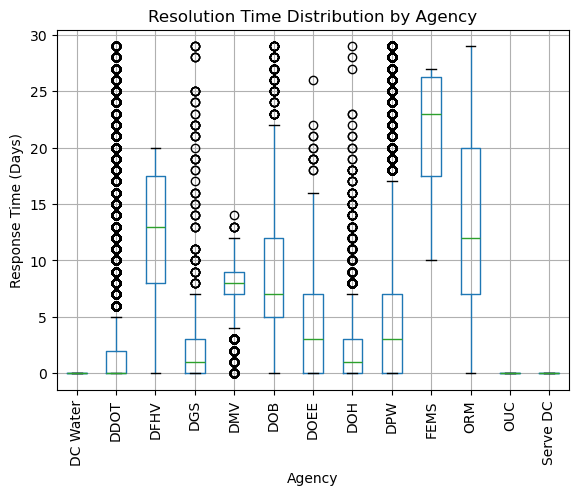

In [487]:
plt.figure()
df.boxplot(column="response_time_days", by="Organization_Acronym")
plt.xlabel("Agency")
plt.ylabel("Response Time (Days)")
plt.title("Resolution Time Distribution by Agency")
plt.xticks(rotation=90)
plt.suptitle("")
plt.show()

#### Interpretation

##### The boxplot reveals variation in response/resolution times between agencies/organizations. The boxplot is a valuable visualization tool as it shows that in agencies deemed "more efficient", there are still extreme delays in resolution, as shown by the plot's outliers. While "Visualization 3:Response Time by Agency" shows that the District Department of Transportation (DDOT) has an average resolution time of just over 2.5 days, this visualization shows that there are extreme outliers in the dataset, with some requests taking over 25 days to resolve.  

#### <u>Visualization 6: Resolution Time Distribution by Ward <u>

#### Statement of Intent 
##### This boxplot examines the spread of response times across each DC Ward, highlighting possible outliers.

<Figure size 640x480 with 0 Axes>

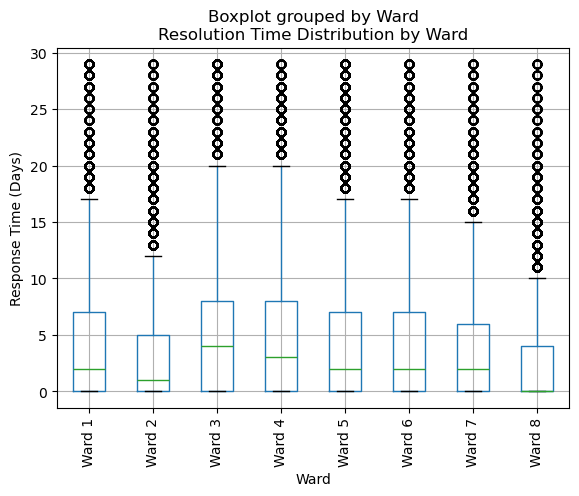

In [488]:
plt.figure()
df.boxplot(column="response_time_days", by="Ward")
plt.xlabel("Ward")
plt.ylabel("Response Time (Days)")
plt.title("Resolution Time Distribution by Ward")
plt.xticks(rotation=90)
plt.show()

#### Interpretation

##### The boxplot reveals variation in response/resolution times between wards. The boxplot is a valuable visualization tool as it shows that even in wards deemed "more efficient", there are still extreme delays in resolution, as shown by the plot's outliers. While "Visualization 4: Response Time by Ward" shows that the Wards 8 and 2 have an average resolution time less than 3.5, this visualization shows that there are extreme outliers in the dataset, with some requests in Wards 8 and 2 taking almost 30 days to resolve.  

#### <u>Visualization 7:  Distribution of Resolution Times <u>

#### Statement of Intent 
##### The histogram examines the distribution of service request resolution times, to present a visualization for resolution times

Text(0.5, 1.0, 'Distribution of Resolution Times')

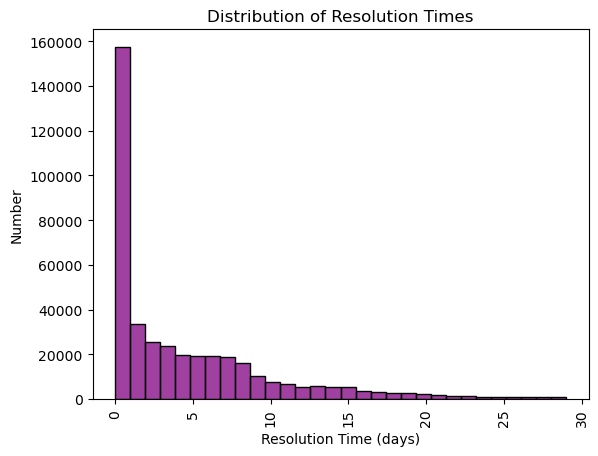

In [489]:
df['Resolution_Date'] = pd.to_datetime(df['Resolution_Date'])
df['Request_Add_Date'] = pd.to_datetime(df['Request_Add_Date'])

df['Resolution_Time'] = (
    df['Resolution_Date'] - df['Request_Add_Date']
).dt.days

sns.histplot(df['Resolution_Time'], bins=30, color="purple")
plt.xlabel("Resolution Time (days)")
plt.ylabel("Number")
plt.xticks(rotation=90)
plt.title("Distribution of Resolution Times")

#### Interpretation

##### The histogram displays the frequency of requests based on the number of days taken to resolve them. A high concentration of requests in the lower day ranges (such as 0–1 days) indicates that most requests are resolved quickly, suggesting efficient service. As the number of days increases, the frequency typically decreases, showing that fewer requests take longer to resolve.

#### <u>Visualization 8: Average Response Time by Service Type and Organization <u>

#### Statement of Intent 
##### The purpose of this visualization is to examine how average response times vary across different service types and organizations

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
 [Text(0, 0, 'SWMA- Solid Waste Management Admistration'),
  Text(1, 0, 'PEMA- Parking Enforcement Management Administration'),
  Text(2, 0, 'Urban Forrestry'),
  Text(3, 0, 'DOH- Department Of Health'),
  Text(4, 0, 'Transportation Operations Administration'),
  Text(5, 0, 'SWMA- Solid Waste Management Administration'),
  Text(6, 0, 'Toa- Trans Sys Mnt'),
  Text(7, 0, 'Department of Buildings (DOB)'),
  Text(8, 0, '311- Call Center'),
  Text(9, 0, 'Toa-Street & Bridge Maintenance'),
  Text(10, 0, 'Department of Energy and Environment'),
  Text(11, 0, 'Department of Transportation'),
  Text(12, 0, 'Adjudication Services'),
  Text(13, 0, 'Driver Vehicle Services'),
  Text(14, 0, 'Serve DC'),
  Text(15, 0, '311- Emergencies'),
  Text(16, 0, 'SIOD'),
  Text(17, 0, 'Transportation Policy & Planning Administration'),
  Text(18, 0, 'DFHV - Department of For-Hire Vehicles'),
  Text(19, 0, 'FEMS'),
  Text(20, 0, 'SNOW

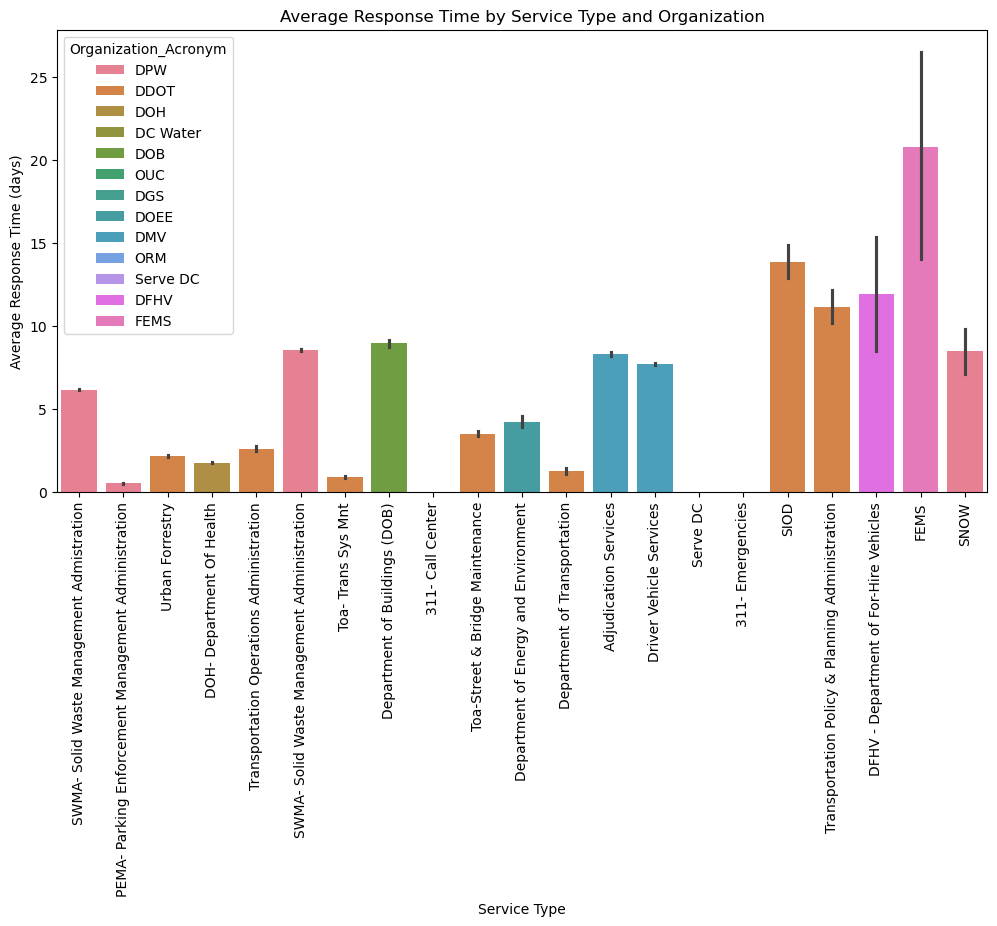

In [490]:
df['Response_Time'] = (
    df['Resolution_Date'] - df['Request_Add_Date']
).dt.days

plt.figure(figsize=(12,6))
sns.barplot(
    data=df,
    x="Service_Type_Code_Description",
    y="Response_Time",
    hue="Organization_Acronym",
    estimator=np.mean
)

plt.title("Average Response Time by Service Type and Organization")
plt.xlabel("Service Type")
plt.ylabel("Average Response Time (days)")
plt.xticks(rotation=90)

#### Interpretation

##### The bar chart shows the average response time for each service type, with different colors representing different service agencies/organizations. Variations in the height of the bar indicate differences in how long it takes each agency to handle specific requests. Certain organizations, like DOH and DOEE, have lower bars across multiple service types; this suggests higher efficiency. While agencies like FEMS and DFHV have taller bars, indicating longer response times and potential delays. Variation between services in the jurisdiction of DDOT indicates potential disparities in manpower or resources, as Urban Forestry-related requests are resolved more swiftly than Transportation Policy concerns. 

## **6) Additonal Analysis/Findings**

#### <u>Visualization 8:  Distribution of Resolution Times <u>

#### Statement of Intent 
##### This visualization examines the relationship between request priority level and resolution time by comparing how long it takes to complete requests across different priority groups. 

Text(0.5, 1.0, 'Resolution Time by Priority Level')

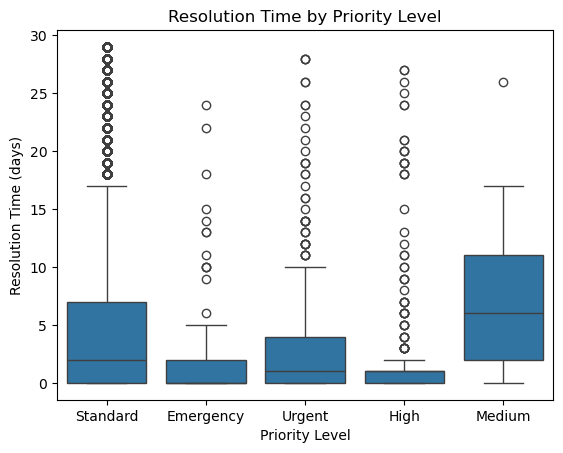

In [491]:
sns.boxplot(data=df, x="Priority", y="Resolution_Time")
plt.xlabel("Priority Level")
plt.ylabel("Resolution Time (days)")
plt.title("Resolution Time by Priority Level")

#### Interpretation

##### This visualization helps assess whether higher-priority requests are handled more efficiently than lower-priority ones. As shown by the boxplot, those marked as "Emergency", "Urgent", or "High" priority demonstrate a smaller range in resolution times, as well as smaller mean, lower quartile, and upper quartile values. 

##### This visualization was created out of curiosity, as I wondered if priority marking would impact response times.

#### <u>Visualization 9: Resolution Times Examined Over the Course of May<u>

#### Statement of Intent 

##### The purpose of this visualization is to examine how resolution time (in days) changes over the course of May

(array([20209., 20213., 20217., 20221., 20225., 20229., 20233., 20237.,
        20240.]),
 [Text(20209.0, 0, '2025-05-01'),
  Text(20213.0, 0, '2025-05-05'),
  Text(20217.0, 0, '2025-05-09'),
  Text(20221.0, 0, '2025-05-13'),
  Text(20225.0, 0, '2025-05-17'),
  Text(20229.0, 0, '2025-05-21'),
  Text(20233.0, 0, '2025-05-25'),
  Text(20237.0, 0, '2025-05-29'),
  Text(20240.0, 0, '2025-06-01')])

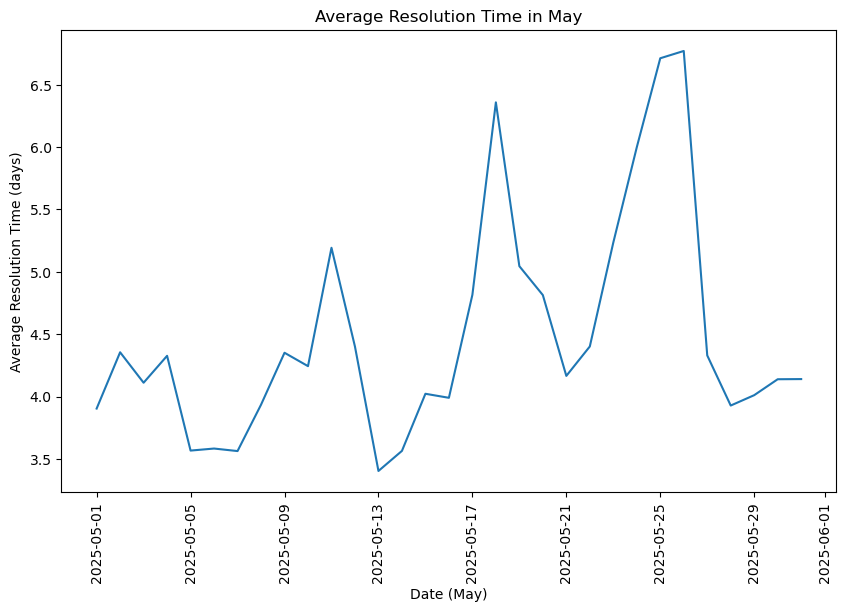

In [492]:
df['Resolution_Time'] = (
    df['Resolution_Date'] - df['Request_Add_Date']
).dt.days

may_data = df[df['Request_Add_Date'].dt.month == 5]
may_daily_avg = may_data.groupby(may_data['Request_Add_Date'].dt.date)['Resolution_Time'].mean()


plt.figure(figsize=(10,6))
sns.lineplot(x=may_daily_avg.index, y=may_daily_avg.values)
plt.title("Average Resolution Time in May")
plt.xlabel("Date (May)")
plt.ylabel("Average Resolution Time (days)")
plt.xticks(rotation=90)

#### Interpretation

##### This line plot shows how resolution times vary across different request submission dates in May. I decided to create this visualization to examine if a noticeable pattern would be made evident. The line plot displays a highly irregular shape, with no clear upward or downward trend; rather, there are frequent spikes and drops across the month. This indicates that resolution times vary significantly from one request to another, suggesting that resolution performance is inconsistent rather than predictable. 

##### While the visualization highlights short-term variability in performance during May, it does not show a clear sustained upward or downward trend. Furthermore, my analysis does not require analysis by month.

#### <u>Visualization 10: Distribution of Requests by Day of the Month<u>

#### Statement of Intent 

##### The purpose of this visualization is to show how service requests are distributed across the days of the month.

Text(0.5, 1.0, 'Distribution of Requests by Day of the Month')

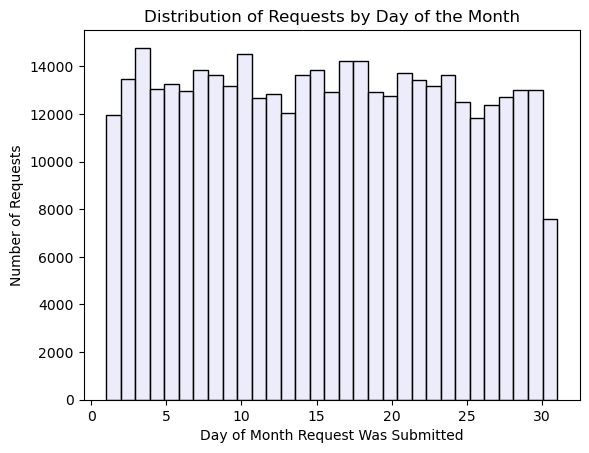

In [493]:
sns.histplot(df['Request_Add_Date'].dt.day, bins=31, color="lavender")
plt.xlabel("Day of Month Request Was Submitted")
plt.ylabel("Number of Requests")
plt.title("Distribution of Requests by Day of the Month")

#### Interpretation

##### The histogram displays the frequency of requests submitted on each day of the month. Possibly, certain days may show higher concentrations of requests, indicating a possible pattern. However, this visualization does not provide insight into how efficiently requests are handled or how response times vary across agencies or regions; it is irrelevant to my analysis.

## **7) Insights and Conclusions**

#### Conclusion

##### This analysis set out to evaluate the efficiency of city service agencies in Washington, DC, by examining response and resolution times, as well as to determine whether significant differences exist in performance across agencies and regions.

#### Research Questions

##### The research questions were partially answered through the analysis. Visualizations of resolution time distributions (Visualization 7) provided insight into overall service efficiency, showing how quickly most requests are completed and highlighting variability in performance. Comparisons across agencies (Visualizations 1, 3, and 5) helped identify whether certain agencies tend to resolve requests faster than others. Furthermore, comparisons exploring the relationship between resolution time and ward (Visualizations 4 and 6) helped identify whether geographic region affected how quickly requests were resolved. Visualization 8 presented an illustration exploring how resolution times vary across different services (even those completed by the same agency) to provide data that details agency-level performance differences.  

#### Significant Patterns and Trends

##### Several key patterns emerged from the visualizations:
- ##### Resolution times were concentrated within a relatively short range, indicating that many requests are handled promptly.
- ##### A right-skewed distribution revealed that while most requests are resolved quickly, a smaller number experience significant delays.
- ##### Boxplots displayed that even in Wards or Agencies deemed efficient, there are still extreme cases in which requests are not handled promptly
- ##### DOB and DMV emerged as bottom-performers with resolution times of 9 and 8 days respectively, indicating inefficiency in the specific agency 

#### Key Insights
##### Overall, the system demonstrates moderate efficiency, with the majority of requests resolved within a few days. Variability in resolution times suggests inconsistency in performance, possibly due to differences in agency workload or the effort it takes to resolve a request. Furthermore, periods of increased resolution time could indicate strain or resource/manpower limitations.

#### Limitations

##### This analysis has several limitations:
- ##### The dataset does not fully account for factors such as request complexity or staffing differences, which may influence resolution time. Possibly, FEMS inefficiency could be explained if these factors were analyzed. 
- ##### Potential missing or inconsistent data entries may affect the accuracy of the results. For example, due to missing values, I had to drop the "Zip Code" column. If included, this column could establish a clearer picture of resolution patterns as determined by the request's geographic/region of origin.

#### Future Directions

##### Future research could expand on this analysis by incorporating request type and agency-level comparisons (agency size, resource availability, funding quantity) to better understand performance differences. Additonally, future research could explore if socioeconomic status influences how quickly a request is resolved and who is marked as a priority to assist. 